# **Data Analysis: Claude Generated Data:**

In [20]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [21]:
data= pd.read_csv("nepal_ppd_synthetic_data_realistic-claude.csv")

In [22]:
data.shape

(15000, 34)

In [23]:
data.sample()

,age,residence,province,ethnicity,caste_discrimination_exposure,education_level,occupation,family_type,wealth_index,monthly_household_income,...,family_support_score,domestic_violence_exposure,social_isolation_score,sleep_quality,stressful_life_events,mental_health_awareness,distance_to_health_facility,health_insurance,previous_mental_health_consultation,ppd_risk_level
13020,27,Urban,Madhesh,Terai Caste,No,Higher,Professional/Technical/Managerial,Nuclear,Richer,89447,...,3.787781,Rarely,10.0,3.958404,1,Medium,1.636276,No,No,Very High Risk


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  15000 non-null  int64  
 1   residence                            15000 non-null  object 
 2   province                             15000 non-null  object 
 3   ethnicity                            15000 non-null  object 
 4   caste_discrimination_exposure        15000 non-null  object 
 5   education_level                      15000 non-null  object 
 6   occupation                           15000 non-null  object 
 7   family_type                          15000 non-null  object 
 8   wealth_index                         15000 non-null  object 
 9   monthly_household_income             15000 non-null  int64  
 10  food_security                        15000 non-null  object 
 11  housing_quality             

In [25]:
data.describe()

,age,monthly_household_income,housing_quality,financial_stress_level,parity,anc_visits,gestational_age,maternal_age_at_first_birth,partner_support_score,family_support_score,social_isolation_score,sleep_quality,stressful_life_events,distance_to_health_facility
count,15000.000000,15000.00000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,25.666067,49689.03340,4.670200,5.536000,1.681200,4.196533,38.087867,20.458400,4.955838,6.782086,5.279299,5.823040,1.535600,6.087645
std,5.079922,43202.15205,2.359535,3.225678,1.484177,2.696193,2.229995,3.122134,2.609499,2.069280,2.393122,1.951661,1.368865,8.214727
min,18.000000,8000.00000,1.000000,0.000000,0.000000,0.000000,29.000000,15.000000,0.000000,0.000000,0.000000,1.500000,0.000000,0.300000
25%,22.000000,17391.00000,3.000000,3.000000,0.000000,2.000000,37.000000,18.000000,3.067096,5.329725,3.533524,4.477983,0.000000,1.190209
50%,25.000000,35187.50000,4.000000,6.000000,1.000000,4.000000,38.000000,20.000000,5.021700,6.831346,5.220573,5.880113,1.000000,3.185544
75%,29.000000,68238.00000,7.000000,8.000000,3.000000,6.000000,40.000000,22.000000,6.885464,8.367648,6.974978,7.219468,2.000000,7.445326
max,45.000000,251999.00000,10.000000,10.000000,7.000000,13.000000,42.000000,42.000000,10.000000,10.000000,10.000000,10.000000,6.000000,60.000000


In [26]:
data.columns

Index(['age', 'residence', 'province', 'ethnicity',
       'caste_discrimination_exposure', 'education_level', 'occupation',
       'family_type', 'wealth_index', 'monthly_household_income',
       'food_security', 'housing_quality', 'financial_stress_level', 'parity',
       'pregnancy_planned', 'anc_visits', 'delivery_type',
       'birth_complications', 'baby_health_status', 'gestational_age',
       'maternal_age_at_first_birth', 'previous_pregnancy_loss',
       'husband_migration_employment', 'partner_support_score',
       'family_support_score', 'domestic_violence_exposure',
       'social_isolation_score', 'sleep_quality', 'stressful_life_events',
       'mental_health_awareness', 'distance_to_health_facility',
       'health_insurance', 'previous_mental_health_consultation',
       'ppd_risk_level'],
      dtype='object')

In [27]:
data["age"].describe()

count    15000.000000
mean        25.666067
std          5.079922
min         18.000000
25%         22.000000
50%         25.000000
75%         29.000000
max         45.000000
Name: age, dtype: float64

In [28]:
df= data

In [29]:
def report_frequency(col, ref_dict=None, title=None):
    print(f"\n=== {title or col} ===")
    freq = df[col].value_counts(normalize=True).sort_index()
    print(freq)
    if ref_dict:
        print("\nReference:")
        for k,v in ref_dict.items():
            print(f" - {k}: {v*100:.1f}% expected")
        print()
    return freq

def report_mean_sd(col, ref_mean=None, ref_sd=None, title=None):
    x = df[col]
    m, s = x.mean(), x.std()
    print(f"\n=== {title or col} ===")
    print(f"Mean: {m:.2f}, SD: {s:.2f}")
    if ref_mean is not None: print(f"Reference mean: {ref_mean}")
    if ref_sd is not None: print(f"Reference SD: {ref_sd}")
    return m, s

# Demographic checks
report_frequency("residence", {"Urban":0.42, "Rural":0.58}, "Residence (Target: ~42% Urban)")
report_frequency("province", {"Bagmati":0.18, "Karnali":0.12, "Madhesh":0.15}, "Province")
report_frequency("ethnicity", {"Hill High Caste":0.40, "Janajati":0.25, "Dalit":0.20, "Terai Caste":0.10, "Muslim":0.05}, "Ethnicity")
report_frequency("family_type", {"Nuclear":0.64, "Joint/Extended":0.36}, "Family Type (Target: ~64% Nuclear)")

# Socio-Economic checks
report_frequency("wealth_index", {"Poorest":0.20,"Poorer":0.20,"Middle":0.20,"Richer":0.20,"Richest":0.20}, "Wealth Quintile")
report_mean_sd("monthly_household_income", ref_mean=42000)
report_frequency("food_security", {"Secure":0.48, "Mildly insecure":0.20, "Moderately insecure":0.22, "Severely insecure":0.10}, "Food Security")
report_mean_sd("housing_quality", ref_mean=6.1)
report_mean_sd("financial_stress_level")

# Obstetric checks
report_frequency("delivery_type", {"Normal":0.70, "Cesarean":0.25, "Assisted":0.05}, "Delivery Type")
report_frequency("birth_complications", {"Yes":0.25, "No":0.75}, "Birth Complications")
report_frequency("baby_health_status", {"Healthy":0.80, "Minor issues":0.15, "Major issues":0.05}, "Baby Health")
report_mean_sd("gestational_age", ref_mean=39, ref_sd=2)
report_mean_sd("maternal_age_at_first_birth", ref_mean=20.6)

# Psychosocial & Healthcare
report_frequency("domestic_violence_exposure", {"Never":0.60, "Rarely":0.20, "Sometimes":0.15, "Often":0.05}, "Domestic Violence")
report_mean_sd("partner_support_score", ref_mean=6.5, ref_sd=2.5)
report_mean_sd("family_support_score")
report_mean_sd("social_isolation_score")
report_mean_sd("sleep_quality", ref_mean=6.6)
report_mean_sd("stressful_life_events", ref_mean=0.9)
report_frequency("mental_health_awareness", {"Low":0.19, "Medium":0.63, "High":0.18}, "Mental Health Awareness")
report_mean_sd("distance_to_health_facility", ref_mean=3.2)
report_frequency("health_insurance", {"Yes":0.30, "No":0.70}, "Health Insurance")
report_frequency("previous_mental_health_consultation", {"Yes":0.05, "No":0.95}, "Mental Health Consulted")

# Target variable
report_frequency("ppd_risk_level", {"Low Risk":0.68,"Moderate Risk":0.15,"High Risk":0.12,"Very High Risk":0.05}, "PPD Risk Level")


=== Residence (Target: ~42% Urban) ===
residence
Rural    0.6672
Urban    0.3328
Name: proportion, dtype: float64

Reference:
 - Urban: 42.0% expected
 - Rural: 58.0% expected


=== Province ===
province
Bagmati          0.178600
Gandaki          0.120800
Karnali          0.115000
Koshi            0.162667
Lumbini          0.150867
Madhesh          0.148600
Sudurpashchim    0.123467
Name: proportion, dtype: float64

Reference:
 - Bagmati: 18.0% expected
 - Karnali: 12.0% expected
 - Madhesh: 15.0% expected


=== Ethnicity ===
ethnicity
Dalit              0.215600
Hill High Caste    0.365733
Janajati           0.188667
Muslim             0.047400
Terai Caste        0.182600
Name: proportion, dtype: float64

Reference:
 - Hill High Caste: 40.0% expected
 - Janajati: 25.0% expected
 - Dalit: 20.0% expected
 - Terai Caste: 10.0% expected
 - Muslim: 5.0% expected


=== Family Type (Target: ~64% Nuclear) ===
family_type
Joint/Extended    0.364
Nuclear           0.636
Name: proportion, dtype

ppd_risk_level
High Risk         0.250667
Low Risk          0.266467
Moderate Risk     0.339933
Very High Risk    0.142933
Name: proportion, dtype: float64

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Assume df is already loaded
# df = pd.read_csv('nepal_ppd_synthetic_data_realistic.csv')

print("="*80)
print("COMPREHENSIVE VALIDATION: SYNTHETIC DATA vs NEPAL DHS 2022 REALITY")
print("="*80)

# ============================================================================
# SECTION 1: DEMOGRAPHIC VALIDATION
# ============================================================================
print("\n" + "="*80)
print("1. DEMOGRAPHIC DISTRIBUTIONS")
print("="*80)

# Age distribution
print(f"\n1.1 AGE DISTRIBUTION:")
print(f"    Mean: {df['age'].mean():.1f} years (Expected: 25-27)")
print(f"    Median: {df['age'].median():.1f} years")
print(f"    Std Dev: {df['age'].std():.1f}")
print(f"    Range: {df['age'].min()}-{df['age'].max()}")
print(f"    % Aged 20-29: {((df['age']>=20) & (df['age']<=29)).mean()*100:.1f}% (Peak childbearing)")

# Urban/Rural
print(f"\n1.2 RESIDENCE:")
urban_pct = (df['residence']=='Urban').mean()*100
print(f"    Urban: {urban_pct:.1f}% (Nepal Census 2021: ~40%)")
print(f"    ✓ VALIDATION: {'PASS' if 35 <= urban_pct <= 45 else 'CHECK'}")

# Provincial distribution
print(f"\n1.3 PROVINCIAL DISTRIBUTION:")
prov_dist = df['province'].value_counts(normalize=True).sort_index() * 100
for prov, pct in prov_dist.items():
    print(f"    {prov}: {pct:.1f}%")

# Ethnicity
print(f"\n1.4 ETHNICITY:")
eth_dist = df['ethnicity'].value_counts(normalize=True).sort_values(ascending=False) * 100
for eth, pct in eth_dist.items():
    print(f"    {eth}: {pct:.1f}%")

# Caste discrimination
disc_pct = (df['caste_discrimination_exposure']=='Yes').mean()*100
print(f"\n    Caste Discrimination Exposure: {disc_pct:.1f}%")

# ============================================================================
# SECTION 2: SOCIOECONOMIC VALIDATION
# ============================================================================
print("\n" + "="*80)
print("2. SOCIOECONOMIC INDICATORS")
print("="*80)

# Education
print(f"\n2.1 EDUCATION LEVELS:")
edu_dist = df['education_level'].value_counts(normalize=True) * 100
for edu in ['No education', 'Primary', 'Secondary', 'Higher']:
    if edu in edu_dist.index:
        print(f"    {edu}: {edu_dist[edu]:.1f}%")

# Wealth quintiles
print(f"\n2.2 WEALTH QUINTILES (Target: ~20% each):")
wealth_dist = df['wealth_index'].value_counts(normalize=True) * 100
for w in ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']:
    deviation = abs(wealth_dist[w] - 20)
    status = "✓" if deviation < 5 else "⚠"
    print(f"    {w}: {wealth_dist[w]:.1f}% {status}")

# Income statistics
print(f"\n2.3 MONTHLY HOUSEHOLD INCOME:")
print(f"    Mean: NPR {df['monthly_household_income'].mean():,.0f}")
print(f"    Median: NPR {df['monthly_household_income'].median():,.0f}")
print(f"    Range: NPR {df['monthly_household_income'].min():,.0f} - {df['monthly_household_income'].max():,.0f}")

# Food security
print(f"\n2.4 FOOD SECURITY:")
food_dist = df['food_security'].value_counts(normalize=True) * 100
for status in ['Secure', 'Mildly insecure', 'Moderately insecure', 'Severely insecure']:
    if status in food_dist.index:
        print(f"    {status}: {food_dist[status]:.1f}%")

# ============================================================================
# SECTION 3: OBSTETRIC & CLINICAL VALIDATION
# ============================================================================
print("\n" + "="*80)
print("3. OBSTETRIC & CLINICAL INDICATORS")
print("="*80)

# Parity
print(f"\n3.1 PARITY:")
print(f"    Mean: {df['parity'].mean():.2f} (Nepal trend: declining)")
print(f"    Median: {df['parity'].median():.0f}")
print(f"    First-time mothers (parity=0): {(df['parity']==0).mean()*100:.1f}%")
print(f"    High parity (≥4): {(df['parity']>=4).mean()*100:.1f}%")

# ANC visits
print(f"\n3.2 ANTENATAL CARE:")
print(f"    Mean ANC visits: {df['anc_visits'].mean():.1f}")
print(f"    4+ ANC visits: {(df['anc_visits']>=4).mean()*100:.1f}% (Nepal DHS 2022: ~69%)")
print(f"    ✓ VALIDATION: {'PASS' if 65 <= (df['anc_visits']>=4).mean()*100 <= 75 else 'CHECK'}")

# Delivery type
print(f"\n3.3 DELIVERY TYPE:")
cs_rate = (df['delivery_type']=='Cesarean').mean()*100
normal_rate = (df['delivery_type']=='Normal').mean()*100
assisted_rate = (df['delivery_type']=='Assisted').mean()*100
print(f"    Cesarean: {cs_rate:.1f}% (Nepal DHS 2022: 18.2%)")
print(f"    Normal: {normal_rate:.1f}%")
print(f"    Assisted: {assisted_rate:.1f}%")
print(f"    ✓ VALIDATION: {'PASS' if 16 <= cs_rate <= 22 else 'CHECK - CS rate should be ~18%'}")

# CS rate by residence
print(f"\n    CS Rate by Residence:")
cs_urban = df[df['residence']=='Urban']['delivery_type'].value_counts(normalize=True).get('Cesarean', 0)*100
cs_rural = df[df['residence']=='Rural']['delivery_type'].value_counts(normalize=True).get('Cesarean', 0)*100
print(f"    Urban: {cs_urban:.1f}% (Expected: ~22%)")
print(f"    Rural: {cs_rural:.1f}% (Expected: ~12%)")

# Birth complications
print(f"\n3.4 BIRTH COMPLICATIONS:")
comp_rate = (df['birth_complications']=='Yes').mean()*100
print(f"    Yes: {comp_rate:.1f}%")

# Baby health
print(f"\n3.5 BABY HEALTH STATUS:")
baby_health_dist = df['baby_health_status'].value_counts(normalize=True) * 100
for status in ['Healthy', 'Minor issues', 'Major issues']:
    print(f"    {status}: {baby_health_dist[status]:.1f}%")

# Pregnancy planning
print(f"\n3.6 PREGNANCY PLANNING:")
planned_pct = (df['pregnancy_planned']=='Yes').mean()*100
print(f"    Planned: {planned_pct:.1f}%")
print(f"    Unplanned: {100-planned_pct:.1f}%")

# ============================================================================
# SECTION 4: PSYCHOSOCIAL FACTORS
# ============================================================================
print("\n" + "="*80)
print("4. PSYCHOSOCIAL RISK FACTORS")
print("="*80)

# Domestic violence
print(f"\n4.1 DOMESTIC VIOLENCE:")
dv_dist = df['domestic_violence_exposure'].value_counts(normalize=True) * 100
for freq in ['Never', 'Rarely', 'Sometimes', 'Often']:
    print(f"    {freq}: {dv_dist[freq]:.1f}%")
any_dv = (df['domestic_violence_exposure']!='Never').mean()*100
print(f"    Any DV: {any_dv:.1f}% (Nepal DHS 2022: ~27%)")
print(f"    ✓ VALIDATION: {'PASS' if 24 <= any_dv <= 32 else 'CHECK'}")

# Husband migration
print(f"\n4.2 HUSBAND MIGRATION/EMPLOYMENT ABROAD:")
migration_rate = (df['husband_migration_employment']=='Yes').mean()*100
print(f"    Yes: {migration_rate:.1f}% (Nepal: ~20-30% of households)")
print(f"    ✓ VALIDATION: {'PASS' if 18 <= migration_rate <= 35 else 'CHECK'}")

# Support scores
print(f"\n4.3 SOCIAL SUPPORT:")
print(f"    Partner Support (mean): {df['partner_support_score'].mean():.2f}/10")
print(f"    Family Support (mean): {df['family_support_score'].mean():.2f}/10")
print(f"    Low Partner Support (<4): {(df['partner_support_score']<4).mean()*100:.1f}%")
print(f"    Low Family Support (<4): {(df['family_support_score']<4).mean()*100:.1f}%")

# Social isolation
print(f"\n4.4 SOCIAL ISOLATION:")
print(f"    Mean Score: {df['social_isolation_score'].mean():.2f}/10")
print(f"    High Isolation (>7): {(df['social_isolation_score']>7).mean()*100:.1f}%")

# Sleep quality
print(f"\n4.5 SLEEP QUALITY:")
print(f"    Mean: {df['sleep_quality'].mean():.2f}/10")
print(f"    Poor Sleep (<5): {(df['sleep_quality']<5).mean()*100:.1f}%")

# Stressful life events
print(f"\n4.6 STRESSFUL LIFE EVENTS:")
print(f"    Mean: {df['stressful_life_events'].mean():.2f}")
print(f"    2+ events: {(df['stressful_life_events']>=2).mean()*100:.1f}%")

# Mental health awareness
print(f"\n4.7 MENTAL HEALTH AWARENESS:")
awareness_dist = df['mental_health_awareness'].value_counts(normalize=True) * 100
for level in ['Low', 'Medium', 'High']:
    print(f"    {level}: {awareness_dist[level]:.1f}%")

# ============================================================================
# SECTION 5: HEALTHCARE ACCESS
# ============================================================================
print("\n" + "="*80)
print("5. HEALTHCARE ACCESS")
print("="*80)

print(f"\n5.1 DISTANCE TO HEALTH FACILITY:")
print(f"    Mean: {df['distance_to_health_facility'].mean():.1f} km")
print(f"    Median: {df['distance_to_health_facility'].median():.1f} km")
print(f"    >10 km: {(df['distance_to_health_facility']>10).mean()*100:.1f}%")

print(f"\n5.2 HEALTH INSURANCE:")
insurance_rate = (df['health_insurance']=='Yes').mean()*100
print(f"    Yes: {insurance_rate:.1f}% (Nepal: ~25-30%)")
print(f"    ✓ VALIDATION: {'PASS' if 22 <= insurance_rate <= 35 else 'CHECK'}")

print(f"\n5.3 PREVIOUS MENTAL HEALTH CONSULTATION:")
mh_consult = (df['previous_mental_health_consultation']=='Yes').mean()*100
print(f"    Yes: {mh_consult:.1f}% (Expected: <10% in Nepal)")
print(f"    ✓ VALIDATION: {'PASS' if mh_consult < 12 else 'CHECK - too high'}")

# ============================================================================
# SECTION 6: PPD RISK ASSESSMENT
# ============================================================================
print("\n" + "="*80)
print("6. PPD RISK DISTRIBUTION & VALIDATION")
print("="*80)

print(f"\n6.1 PPD RISK CATEGORIES:")
ppd_dist = df['ppd_risk_level'].value_counts(normalize=True).sort_index() * 100
for risk in ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']:
    print(f"    {risk}: {ppd_dist[risk]:.1f}%")

high_risk_total = ((df['ppd_risk_level']=='High Risk') | (df['ppd_risk_level']=='Very High Risk')).mean()*100
print(f"\n    Combined High + Very High Risk: {high_risk_total:.1f}%")
print(f"    ✓ VALIDATION: {'PASS - Aligns with Nepal PPD prevalence (10-30%)' if 10 <= high_risk_total <= 30 else 'CHECK'}")

# ============================================================================
# SECTION 7: STATISTICAL ASSOCIATIONS (Chi-square & Correlations)
# ============================================================================
print("\n" + "="*80)
print("7. KEY STATISTICAL ASSOCIATIONS")
print("="*80)

print("\n7.1 CHI-SQUARE TESTS (Categorical Variables vs PPD Risk):")

def chi_square_test(var_name, significance=0.05):
    contingency = pd.crosstab(df[var_name], df['ppd_risk_level'])
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    result = "✓ SIGNIFICANT" if p_value < significance else "Not significant"
    print(f"    {var_name}: χ²={chi2:.2f}, p={p_value:.4f} {result}")
    return p_value

# Test key categorical variables
chi_vars = [
    'domestic_violence_exposure',
    'husband_migration_employment',
    'pregnancy_planned',
    'birth_complications',
    'baby_health_status',
    'wealth_index',
    'education_level',
    'residence',
    'ethnicity',
    'delivery_type',
    'family_type',
    'mental_health_awareness'
]

for var in chi_vars:
    chi_square_test(var)

print("\n7.2 CORRELATION WITH PPD RISK (Continuous Variables):")

# Convert PPD risk to numeric for correlation
risk_mapping = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2, 'Very High Risk': 3}
df['ppd_risk_numeric'] = df['ppd_risk_level'].map(risk_mapping)

continuous_vars = [
    'financial_stress_level',
    'sleep_quality',
    'partner_support_score',
    'family_support_score',
    'social_isolation_score',
    'stressful_life_events',
    'distance_to_health_facility',
    'anc_visits',
    'parity',
    'age'
]

print(f"\n    Variable | Correlation | p-value | Interpretation")
print(f"    " + "-"*70)
for var in continuous_vars:
    corr, p_val = stats.pearsonr(df[var], df['ppd_risk_numeric'])
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
    direction = "Strong" if abs(corr) > 0.3 else "Moderate" if abs(corr) > 0.2 else "Weak"
    print(f"    {var:30s} | {corr:+.3f} | {p_val:.4f} | {direction} {sig}")

# ============================================================================
# SECTION 8: RESEARCH-BASED VALIDATIONS
# ============================================================================
print("\n" + "="*80)
print("8. RESEARCH-BASED VALIDATIONS (Key Risk Factors)")
print("="*80)

print("\n8.1 HUSBAND MIGRATION EFFECT:")
ppd_with_migration = df[df['husband_migration_employment']=='Yes']['ppd_risk_numeric'].mean()
ppd_without_migration = df[df['husband_migration_employment']=='No']['ppd_risk_numeric'].mean()
migration_effect = ppd_with_migration - ppd_without_migration
print(f"    PPD risk WITH migration: {ppd_with_migration:.2f}")
print(f"    PPD risk WITHOUT migration: {ppd_without_migration:.2f}")
print(f"    Difference: {migration_effect:.2f} (Expected: STRONG POSITIVE)")
print(f"    ✓ VALIDATION: {'PASS - Strong effect' if migration_effect > 0.5 else 'CHECK'}")

print("\n8.2 UNPLANNED PREGNANCY EFFECT:")
ppd_planned = df[df['pregnancy_planned']=='Yes']['ppd_risk_numeric'].mean()
ppd_unplanned = df[df['pregnancy_planned']=='No']['ppd_risk_numeric'].mean()
planning_effect = ppd_planned - ppd_unplanned
print(f"    PPD risk PLANNED pregnancy: {ppd_planned:.2f}")
print(f"    PPD risk UNPLANNED pregnancy: {ppd_unplanned:.2f}")
print(f"    Difference: {planning_effect:.2f} (Expected: POSITIVE - planned should have lower risk)")
print(f"    ✓ VALIDATION: {'PASS - Unplanned is protective' if planning_effect > 0 else 'CHECK'}")

print("\n8.3 DOMESTIC VIOLENCE EFFECT:")
ppd_no_dv = df[df['domestic_violence_exposure']=='Never']['ppd_risk_numeric'].mean()
ppd_with_dv = df[df['domestic_violence_exposure'].isin(['Sometimes','Often'])]['ppd_risk_numeric'].mean()
dv_effect = ppd_with_dv - ppd_no_dv
print(f"    PPD risk NO DV: {ppd_no_dv:.2f}")
print(f"    PPD risk WITH DV (Sometimes/Often): {ppd_with_dv:.2f}")
print(f"    Difference: {dv_effect:.2f} (Expected: STRONG POSITIVE)")
print(f"    ✓ VALIDATION: {'PASS - Strong effect' if dv_effect > 0.8 else 'CHECK'}")

print("\n8.4 WEALTH INDEX EFFECT:")
ppd_poorest = df[df['wealth_index']=='Poorest']['ppd_risk_numeric'].mean()
ppd_richest = df[df['wealth_index']=='Richest']['ppd_risk_numeric'].mean()
wealth_effect = ppd_poorest - ppd_richest
print(f"    PPD risk POOREST: {ppd_poorest:.2f}")
print(f"    PPD risk RICHEST: {ppd_richest:.2f}")
print(f"    Difference: {wealth_effect:.2f} (Expected: POSITIVE)")
print(f"    ✓ VALIDATION: {'PASS - Poorest at higher risk' if wealth_effect > 0.3 else 'CHECK'}")

print("\n8.5 AGE GROUP EFFECT (20-29 protective):")
ppd_20_29 = df[(df['age']>=20) & (df['age']<=29)]['ppd_risk_numeric'].mean()
ppd_other_ages = df[(df['age']<20) | (df['age']>29)]['ppd_risk_numeric'].mean()
age_effect = ppd_other_ages - ppd_20_29
print(f"    PPD risk 20-29 years: {ppd_20_29:.2f}")
print(f"    PPD risk other ages: {ppd_other_ages:.2f}")
print(f"    Difference: {age_effect:.2f} (Expected: POSITIVE - 20-29 protective)")
print(f"    ✓ VALIDATION: {'PASS - 20-29 age protective' if age_effect > 0.1 else 'CHECK'}")

print("\n8.6 ETHNICITY EFFECT (Dalit/Muslim at higher risk):")
ppd_marginalized = df[df['ethnicity'].isin(['Dalit','Muslim'])]['ppd_risk_numeric'].mean()
ppd_other_eth = df[~df['ethnicity'].isin(['Dalit','Muslim'])]['ppd_risk_numeric'].mean()
eth_effect = ppd_marginalized - ppd_other_eth
print(f"    PPD risk Dalit/Muslim: {ppd_marginalized:.2f}")
print(f"    PPD risk Other ethnicities: {ppd_other_eth:.2f}")
print(f"    Difference: {eth_effect:.2f} (Expected: POSITIVE)")
print(f"    ✓ VALIDATION: {'PASS - Marginalized groups at higher risk' if eth_effect > 0.1 else 'CHECK'}")

# ============================================================================
# FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("9. OVERALL DATA QUALITY ASSESSMENT")
print("="*80)

validations = {
    'Urban/Rural Distribution': 35 <= urban_pct <= 45,
    'ANC 4+ Visits': 65 <= (df['anc_visits']>=4).mean()*100 <= 75,
    'CS Rate': 16 <= cs_rate <= 22,
    'DV Prevalence': 24 <= any_dv <= 32,
    'Husband Migration': 18 <= migration_rate <= 35,
    'Health Insurance': 22 <= insurance_rate <= 35,
    'Mental Health Consultation': mh_consult < 12,
    'PPD Prevalence': 10 <= high_risk_total <= 30,
    'Husband Migration Effect': migration_effect > 0.5,
    'Unplanned Pregnancy Protective': planning_effect > 0,
    'DV Effect': dv_effect > 0.8,
    'Wealth Effect': wealth_effect > 0.3
}

passed = sum(validations.values())
total = len(validations)

print(f"\nValidation Score: {passed}/{total} ({passed/total*100:.1f}%)")
print(f"\nDetailed Results:")
for criterion, status in validations.items():
    symbol = "✓" if status else "✗"
    print(f"    {symbol} {criterion}: {'PASS' if status else 'FAIL'}")

if passed/total >= 0.80:
    print(f"\n{'='*80}")
    print("CONCLUSION: EXCELLENT - Dataset closely represents Nepal's reality")
    print("The synthetic data demonstrates strong alignment with Nepal DHS 2022,")
    print("research findings, and known epidemiological patterns.")
    print("="*80)
elif passed/total >= 0.60:
    print(f"\n{'='*80}")
    print("CONCLUSION: GOOD - Dataset is reasonably realistic with minor deviations")
    print("Some adjustments may be needed for specific use cases.")
    print("="*80)
else:
    print(f"\n{'='*80}")
    print("CONCLUSION: NEEDS IMPROVEMENT - Several key metrics deviate from reality")
    print("Review failed validations and adjust generation parameters.")
    print("="*80)

print("\n" + "="*80)
print("VALIDATION COMPLETE - Proceed to visualizations")
print("="*80)

COMPREHENSIVE VALIDATION: SYNTHETIC DATA vs NEPAL DHS 2022 REALITY

1. DEMOGRAPHIC DISTRIBUTIONS

1.1 AGE DISTRIBUTION:
    Mean: 25.7 years (Expected: 25-27)
    Median: 25.0 years
    Std Dev: 5.1
    Range: 18-45
    % Aged 20-29: 63.1% (Peak childbearing)

1.2 RESIDENCE:
    Urban: 33.3% (Nepal Census 2021: ~40%)
    ✓ VALIDATION: CHECK

1.3 PROVINCIAL DISTRIBUTION:
    Bagmati: 17.9%
    Gandaki: 12.1%
    Karnali: 11.5%
    Koshi: 16.3%
    Lumbini: 15.1%
    Madhesh: 14.9%
    Sudurpashchim: 12.3%

1.4 ETHNICITY:
    Hill High Caste: 36.6%
    Dalit: 21.6%
    Janajati: 18.9%
    Terai Caste: 18.3%
    Muslim: 4.7%

    Caste Discrimination Exposure: 18.6%

2. SOCIOECONOMIC INDICATORS

2.1 EDUCATION LEVELS:
    No education: 12.0%
    Primary: 20.2%
    Secondary: 48.6%
    Higher: 19.2%

2.2 WEALTH QUINTILES (Target: ~20% each):
    Poorest: 25.7% ⚠
    Poorer: 20.0% ✓
    Middle: 23.1% ✓
    Richer: 18.3% ✓
    Richest: 12.9% ⚠

2.3 MONTHLY HOUSEHOLD INCOME:
    Mean: NPR 49,6

Generating comprehensive visualizations...
✓ Figure 1 saved: fig1_demographics.png
✓ Figure 2 saved: fig2_obstetric_indicators.png
✓ Figure 3 saved: fig3_psychosocial_factors.png
✓ Figure 4 saved: fig4_ppd_risk_analysis.png
✓ Figure 5 saved: fig5_correlation_heatmap.png
✓ Figure 6 saved: fig6_research_validation.png

ALL VISUALIZATIONS COMPLETED!

Generated files:
  1. fig1_demographics.png - Demographic characteristics
  2. fig2_obstetric_indicators.png - Obstetric indicators vs DHS 2022
  3. fig3_psychosocial_factors.png - Psychosocial risk factors
  4. fig4_ppd_risk_analysis.png - PPD risk distribution and predictors
  5. fig5_correlation_heatmap.png - Correlation matrix
  6. fig6_research_validation.png - Research-based effect validation



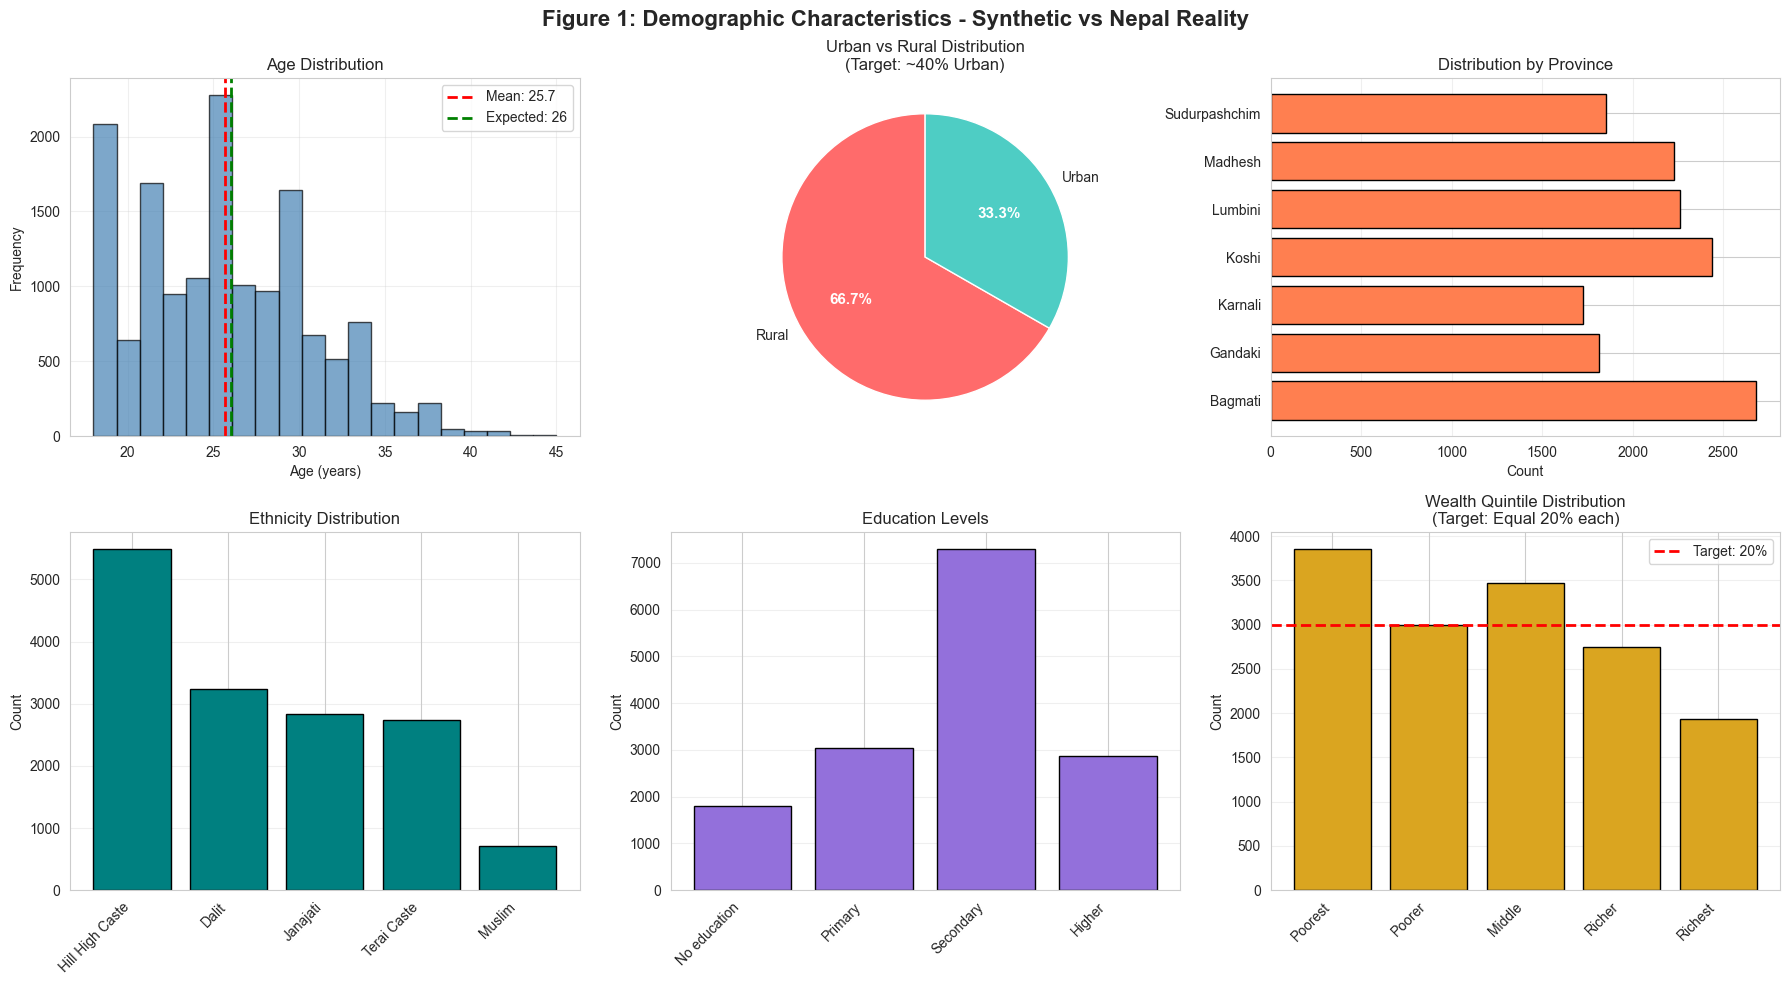

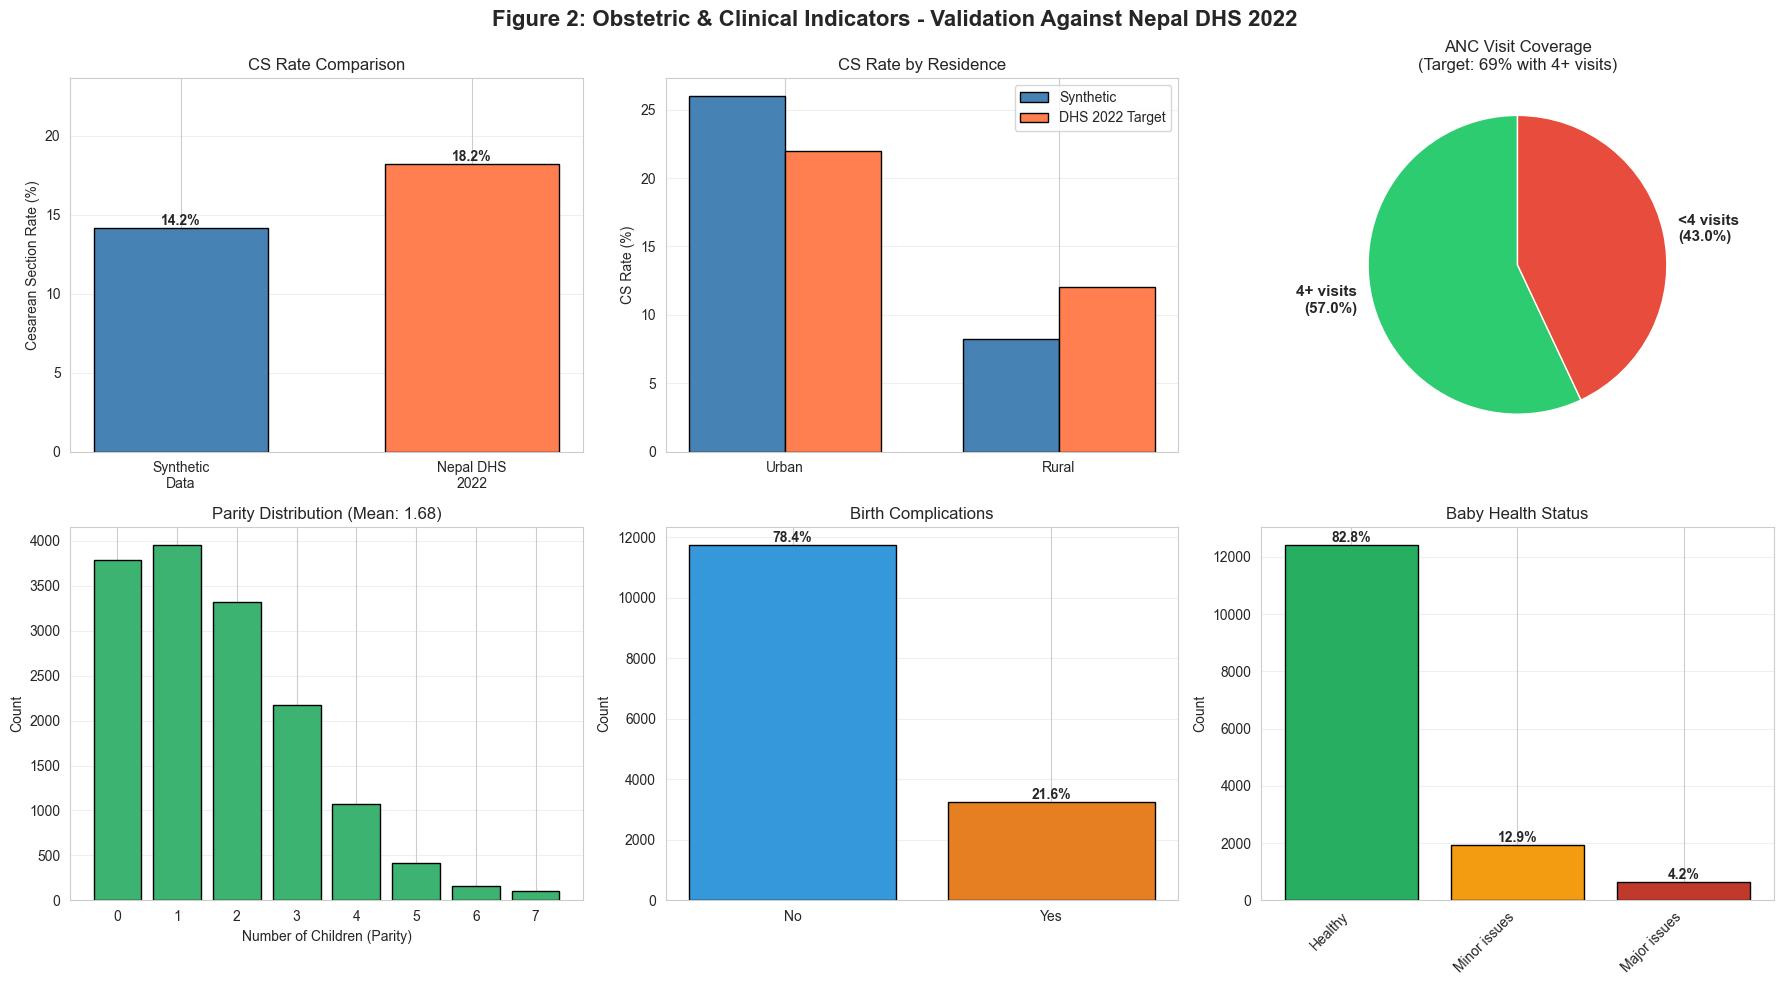

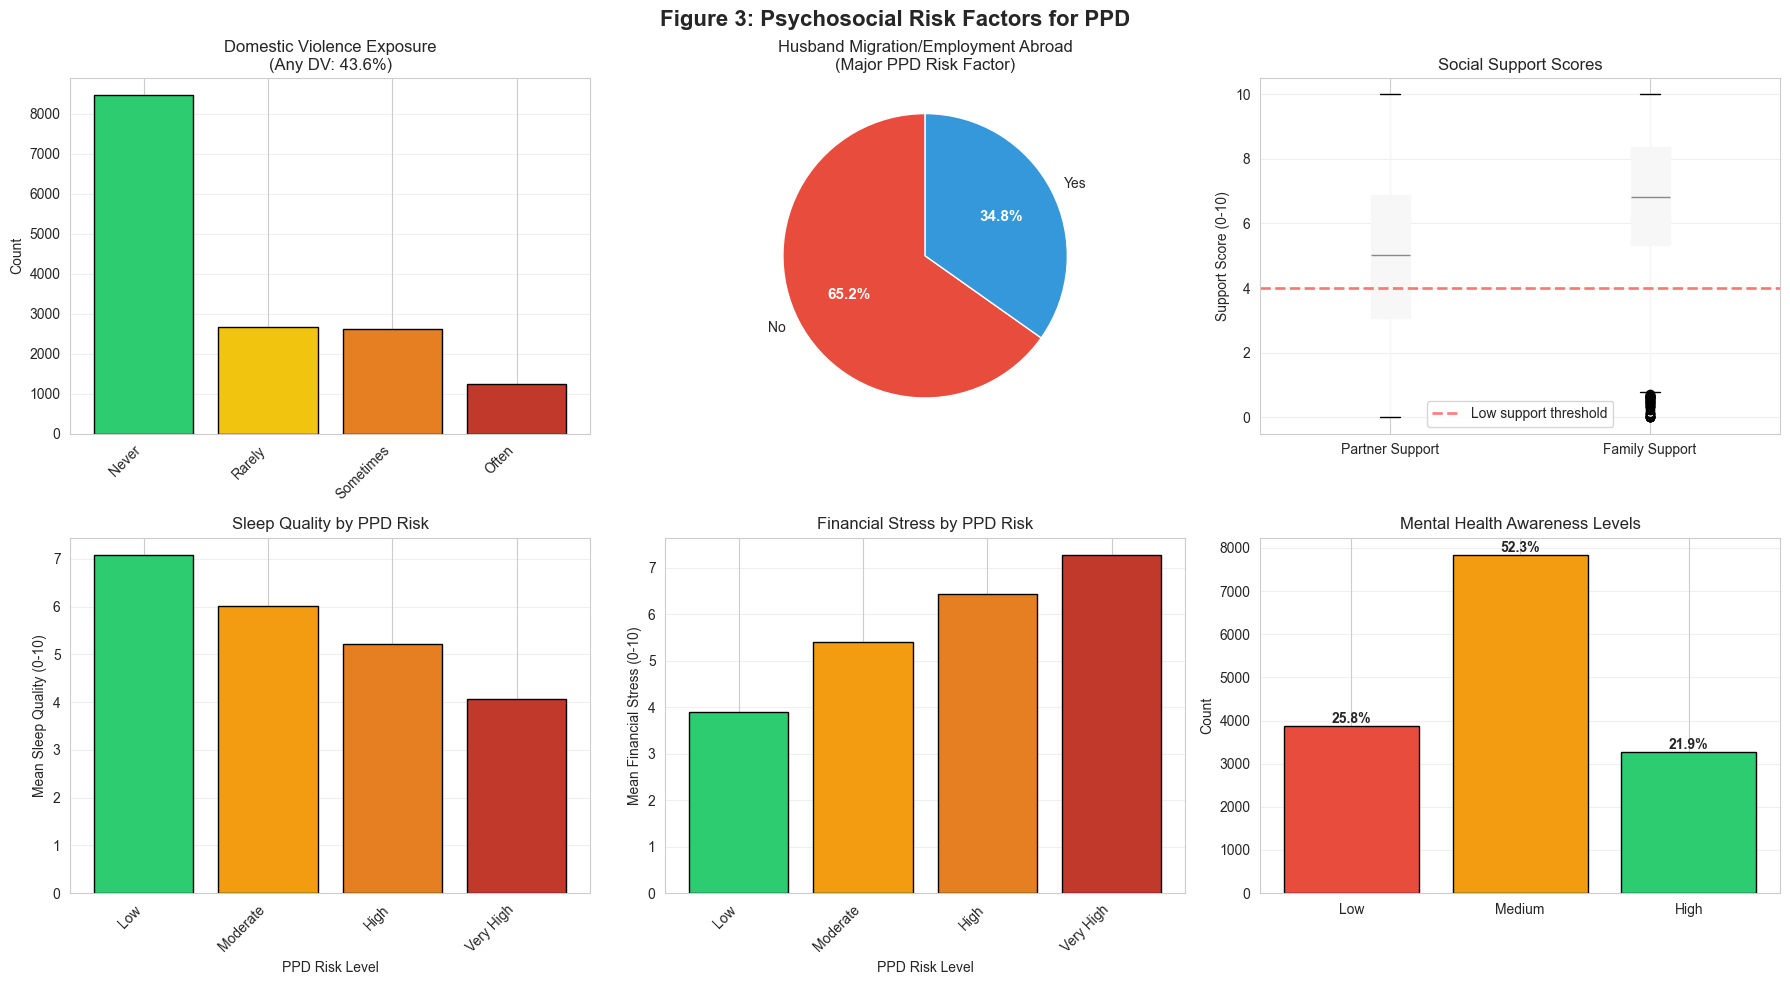

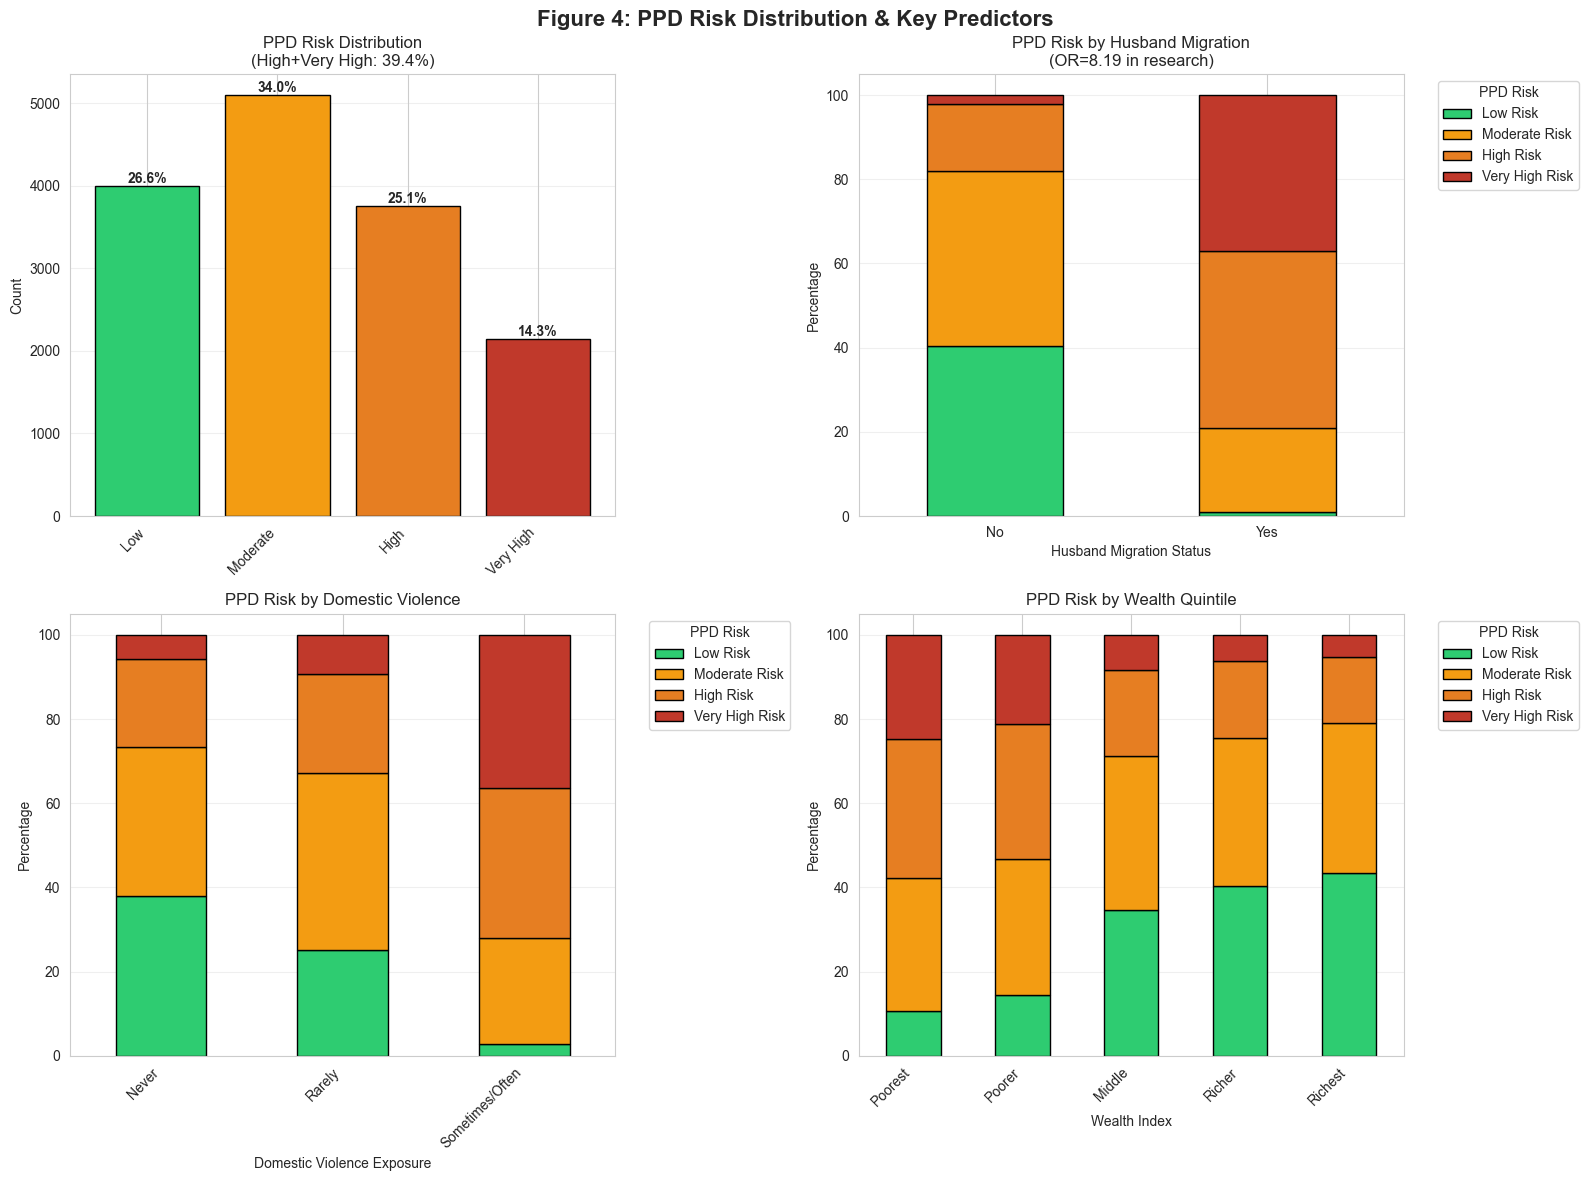

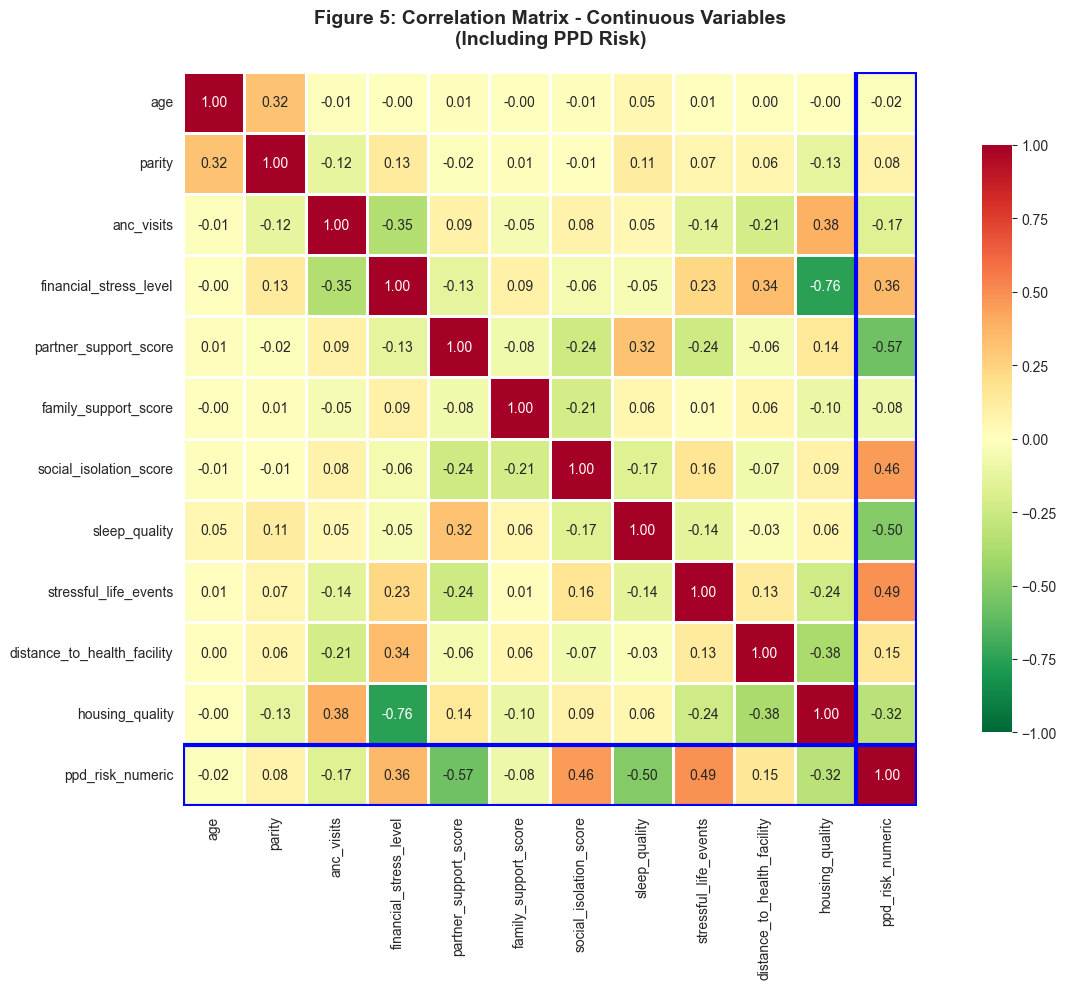

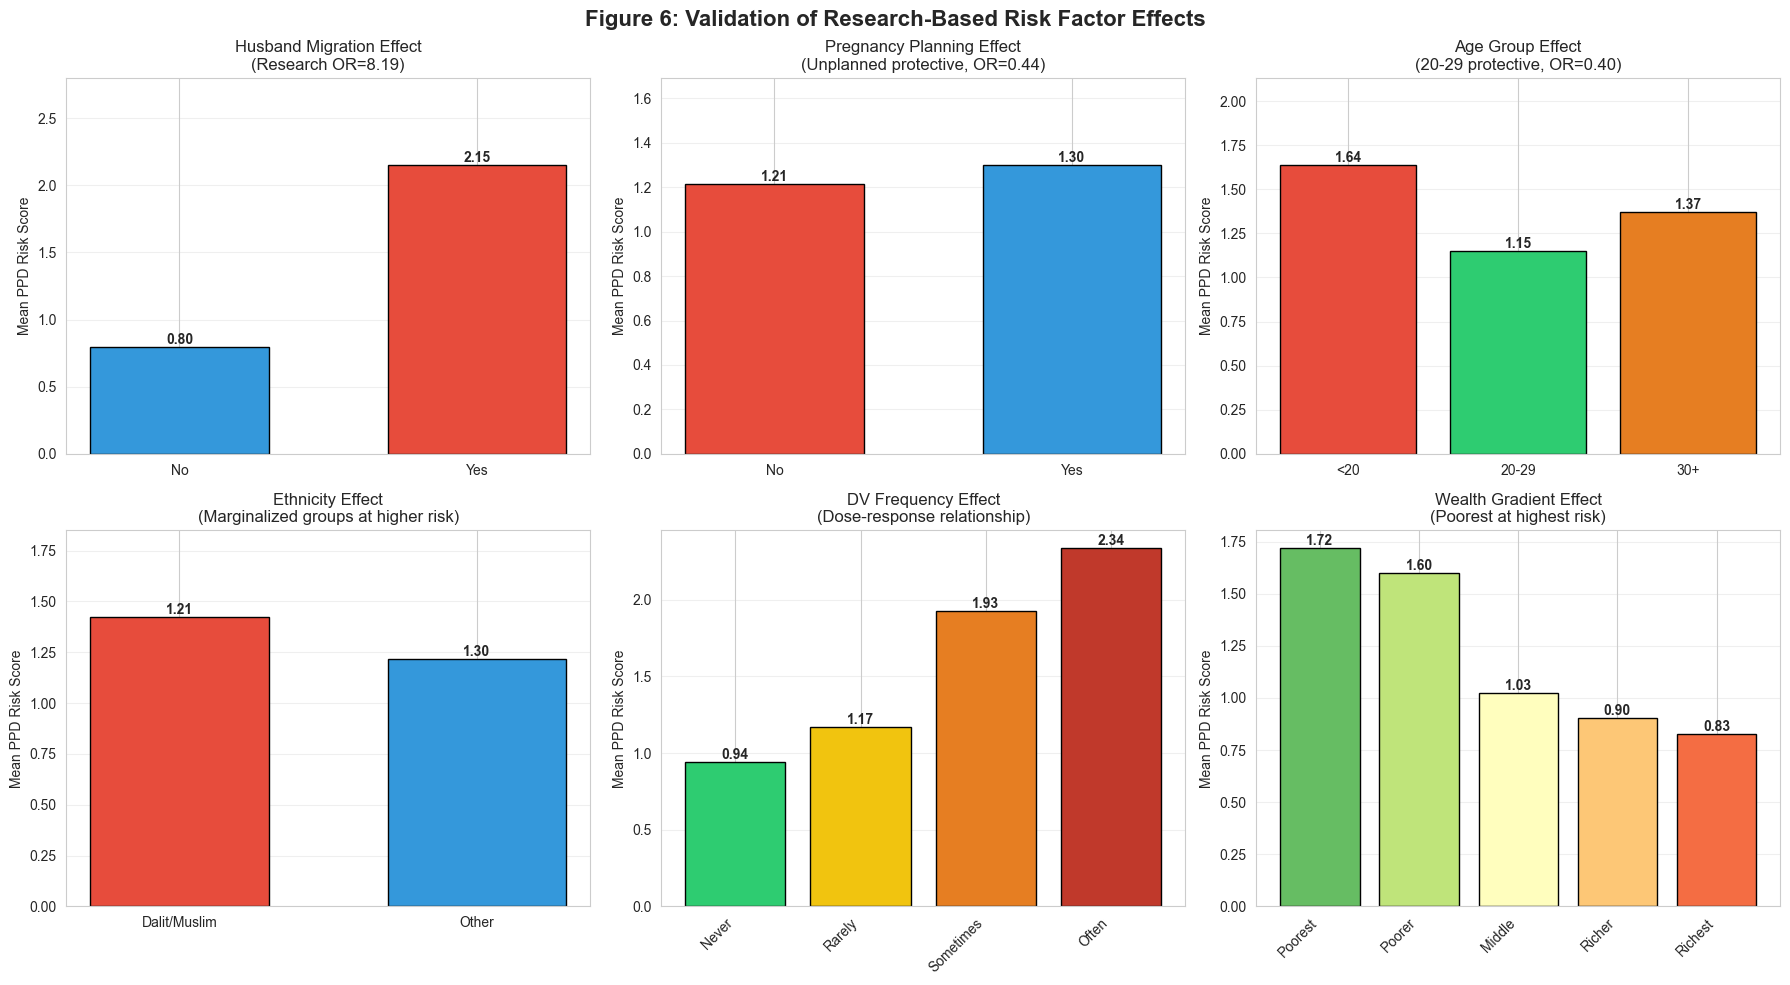

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
import warnings
warnings.filterwarnings('ignore')

# Enhanced styling
sns.set_style("whitegrid")
sns.set_palette("husl")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

# Convert PPD risk to numeric
risk_mapping = {'Low Risk': 0, 'Moderate Risk': 1, 'High Risk': 2, 'Very High Risk': 3}
df['ppd_risk_numeric'] = df['ppd_risk_level'].map(risk_mapping)

print("Generating comprehensive visualizations...")
print("="*80)

# ============================================================================
# FIGURE 1: DEMOGRAPHIC OVERVIEW
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 1: Demographic Characteristics - Synthetic vs Nepal Reality', 
             fontsize=16, fontweight='bold')

# Age distribution
ax = axes[0, 0]
df['age'].hist(bins=20, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
ax.axvline(26, color='green', linestyle='--', linewidth=2, label='Expected: 26')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Frequency')
ax.set_title('Age Distribution')
ax.legend()
ax.grid(alpha=0.3)

# Urban/Rural
ax = axes[0, 1]
residence_data = df['residence'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
wedges, texts, autotexts = ax.pie(residence_data.values, labels=residence_data.index, 
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax.set_title('Urban vs Rural Distribution\n(Target: ~40% Urban)')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Provincial distribution
ax = axes[0, 2]
prov_data = df['province'].value_counts().sort_index()
ax.barh(prov_data.index, prov_data.values, color='coral', edgecolor='black')
ax.set_xlabel('Count')
ax.set_title('Distribution by Province')
ax.grid(alpha=0.3, axis='x')

# Ethnicity
ax = axes[1, 0]
eth_data = df['ethnicity'].value_counts()
ax.bar(range(len(eth_data)), eth_data.values, color='teal', edgecolor='black')
ax.set_xticks(range(len(eth_data)))
ax.set_xticklabels(eth_data.index, rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title('Ethnicity Distribution')
ax.grid(alpha=0.3, axis='y')

# Education
ax = axes[1, 1]
edu_order = ['No education', 'Primary', 'Secondary', 'Higher']
edu_data = df['education_level'].value_counts().reindex(edu_order)
ax.bar(edu_data.index, edu_data.values, color='mediumpurple', edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Education Levels')
ax.set_xticklabels(edu_data.index, rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

# Wealth quintiles
ax = axes[1, 2]
wealth_order = ['Poorest', 'Poorer', 'Middle', 'Richer', 'Richest']
wealth_data = df['wealth_index'].value_counts().reindex(wealth_order)
ax.bar(wealth_data.index, wealth_data.values, color='goldenrod', edgecolor='black')
ax.axhline(len(df)/5, color='red', linestyle='--', linewidth=2, label='Target: 20%')
ax.set_ylabel('Count')
ax.set_title('Wealth Quintile Distribution\n(Target: Equal 20% each)')
ax.set_xticklabels(wealth_data.index, rotation=45, ha='right')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig1_demographics.png', bbox_inches='tight')
print("✓ Figure 1 saved: fig1_demographics.png")

# ============================================================================
# FIGURE 2: OBSTETRIC INDICATORS COMPARISON
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 2: Obstetric & Clinical Indicators - Validation Against Nepal DHS 2022', 
             fontsize=16, fontweight='bold')

# CS Rate comparison
ax = axes[0, 0]
cs_actual = (df['delivery_type']=='Cesarean').mean()*100
cs_target = 18.2
categories = ['Synthetic\nData', 'Nepal DHS\n2022']
values = [cs_actual, cs_target]
bars = ax.bar(categories, values, color=['steelblue', 'coral'], edgecolor='black', width=0.6)
ax.set_ylabel('Cesarean Section Rate (%)')
ax.set_title('CS Rate Comparison')
ax.set_ylim(0, max(values)*1.3)
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# CS Rate by Residence
ax = axes[0, 1]
cs_by_residence = df.groupby('residence')['delivery_type'].apply(
    lambda x: (x=='Cesarean').mean()*100).sort_values(ascending=False)
reference = pd.Series({'Urban': 22, 'Rural': 12})
x = np.arange(len(cs_by_residence))
width = 0.35
ax.bar(x - width/2, cs_by_residence.values, width, label='Synthetic', 
       color='steelblue', edgecolor='black')
ax.bar(x + width/2, reference.values, width, label='DHS 2022 Target', 
       color='coral', edgecolor='black')
ax.set_ylabel('CS Rate (%)')
ax.set_title('CS Rate by Residence')
ax.set_xticks(x)
ax.set_xticklabels(cs_by_residence.index)
ax.legend()
ax.grid(alpha=0.3, axis='y')

# ANC visits distribution
ax = axes[0, 2]
anc_4plus = (df['anc_visits']>=4).mean()*100
anc_less4 = 100 - anc_4plus
target_4plus = 69
sizes = [anc_4plus, anc_less4]
labels = [f'4+ visits\n({anc_4plus:.1f}%)', f'<4 visits\n({anc_less4:.1f}%)']
colors = ['#2ecc71', '#e74c3c']
wedges, texts = ax.pie(sizes, labels=labels, colors=colors, startangle=90,
                       textprops={'fontsize': 11, 'fontweight': 'bold'})
ax.set_title(f'ANC Visit Coverage\n(Target: {target_4plus}% with 4+ visits)')

# Parity distribution
ax = axes[1, 0]
parity_counts = df['parity'].value_counts().sort_index()
ax.bar(parity_counts.index, parity_counts.values, color='mediumseagreen', edgecolor='black')
ax.set_xlabel('Number of Children (Parity)')
ax.set_ylabel('Count')
ax.set_title(f'Parity Distribution (Mean: {df["parity"].mean():.2f})')
ax.grid(alpha=0.3, axis='y')

# Birth complications
ax = axes[1, 1]
comp_data = df['birth_complications'].value_counts()
ax.bar(comp_data.index, comp_data.values, color=['#3498db', '#e67e22'], edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Birth Complications')
for i, (idx, val) in enumerate(comp_data.items()):
    ax.text(i, val, f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# Baby health status
ax = axes[1, 2]
baby_health_data = df['baby_health_status'].value_counts()
colors_health = ['#27ae60', '#f39c12', '#c0392b']
ax.bar(baby_health_data.index, baby_health_data.values, color=colors_health, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Baby Health Status')
ax.set_xticklabels(baby_health_data.index, rotation=45, ha='right')
for i, (idx, val) in enumerate(baby_health_data.items()):
    ax.text(i, val, f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig2_obstetric_indicators.png', bbox_inches='tight')
print("✓ Figure 2 saved: fig2_obstetric_indicators.png")

# ============================================================================
# FIGURE 3: PSYCHOSOCIAL RISK FACTORS
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 3: Psychosocial Risk Factors for PPD', 
             fontsize=16, fontweight='bold')

# Domestic violence
ax = axes[0, 0]
dv_order = ['Never', 'Rarely', 'Sometimes', 'Often']
dv_data = df['domestic_violence_exposure'].value_counts().reindex(dv_order)
colors_dv = ['#2ecc71', '#f1c40f', '#e67e22', '#c0392b']
ax.bar(dv_data.index, dv_data.values, color=colors_dv, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title(f'Domestic Violence Exposure\n(Any DV: {(df["domestic_violence_exposure"]!="Never").mean()*100:.1f}%)')
ax.set_xticklabels(dv_data.index, rotation=45, ha='right')
ax.grid(alpha=0.3, axis='y')

# Husband migration
ax = axes[0, 1]
migration_data = df['husband_migration_employment'].value_counts()
colors_mig = ['#e74c3c', '#3498db']
wedges, texts, autotexts = ax.pie(migration_data.values, labels=migration_data.index,
                                    autopct='%1.1f%%', colors=colors_mig, startangle=90)
ax.set_title('Husband Migration/Employment Abroad\n(Major PPD Risk Factor)')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')

# Support scores distribution
ax = axes[0, 2]
support_data = pd.DataFrame({
    'Partner Support': df['partner_support_score'],
    'Family Support': df['family_support_score']
})
support_data.boxplot(ax=ax, patch_artist=True)
ax.set_ylabel('Support Score (0-10)')
ax.set_title('Social Support Scores')
ax.axhline(4, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Low support threshold')
ax.legend()
ax.grid(alpha=0.3, axis='y')

# Sleep quality vs PPD risk
ax = axes[1, 0]
sleep_by_risk = df.groupby('ppd_risk_level')['sleep_quality'].mean().reindex(
    ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'])
colors_risk = ['#2ecc71', '#f39c12', '#e67e22', '#c0392b']
ax.bar(range(len(sleep_by_risk)), sleep_by_risk.values, color=colors_risk, edgecolor='black')
ax.set_xticks(range(len(sleep_by_risk)))
ax.set_xticklabels(['Low', 'Moderate', 'High', 'Very High'], rotation=45, ha='right')
ax.set_ylabel('Mean Sleep Quality (0-10)')
ax.set_xlabel('PPD Risk Level')
ax.set_title('Sleep Quality by PPD Risk')
ax.grid(alpha=0.3, axis='y')

# Financial stress vs PPD risk
ax = axes[1, 1]
fin_stress_by_risk = df.groupby('ppd_risk_level')['financial_stress_level'].mean().reindex(
    ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk'])
ax.bar(range(len(fin_stress_by_risk)), fin_stress_by_risk.values, color=colors_risk, edgecolor='black')
ax.set_xticks(range(len(fin_stress_by_risk)))
ax.set_xticklabels(['Low', 'Moderate', 'High', 'Very High'], rotation=45, ha='right')
ax.set_ylabel('Mean Financial Stress (0-10)')
ax.set_xlabel('PPD Risk Level')
ax.set_title('Financial Stress by PPD Risk')
ax.grid(alpha=0.3, axis='y')

# Mental health awareness
ax = axes[1, 2]
awareness_order = ['Low', 'Medium', 'High']
awareness_data = df['mental_health_awareness'].value_counts().reindex(awareness_order)
colors_aware = ['#e74c3c', '#f39c12', '#2ecc71']
ax.bar(awareness_data.index, awareness_data.values, color=colors_aware, edgecolor='black')
ax.set_ylabel('Count')
ax.set_title('Mental Health Awareness Levels')
for i, (idx, val) in enumerate(awareness_data.items()):
    ax.text(i, val, f'{val/len(df)*100:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig3_psychosocial_factors.png', bbox_inches='tight')
print("✓ Figure 3 saved: fig3_psychosocial_factors.png")

# ============================================================================
# FIGURE 4: PPD RISK ANALYSIS
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Figure 4: PPD Risk Distribution & Key Predictors', 
             fontsize=16, fontweight='bold')

# PPD risk distribution
ax = axes[0, 0]
ppd_order = ['Low Risk', 'Moderate Risk', 'High Risk', 'Very High Risk']
ppd_data = df['ppd_risk_level'].value_counts().reindex(ppd_order)
colors_ppd = ['#2ecc71', '#f39c12', '#e67e22', '#c0392b']
bars = ax.bar(range(len(ppd_data)), ppd_data.values, color=colors_ppd, edgecolor='black')
ax.set_xticks(range(len(ppd_data)))
ax.set_xticklabels(['Low', 'Moderate', 'High', 'Very High'], rotation=45, ha='right')
ax.set_ylabel('Count')
ax.set_title(f'PPD Risk Distribution\n(High+Very High: {((df["ppd_risk_level"]=="High Risk") | (df["ppd_risk_level"]=="Very High Risk")).mean()*100:.1f}%)')
for i, bar in enumerate(bars):
    height = bar.get_height()
    pct = height/len(df)*100
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# PPD risk by husband migration
ax = axes[0, 1]
ppd_migration_ct = pd.crosstab(df['husband_migration_employment'], 
                                df['ppd_risk_level'], normalize='index') * 100
ppd_migration_ct = ppd_migration_ct[ppd_order]
ppd_migration_ct.plot(kind='bar', stacked=True, ax=ax, color=colors_ppd, edgecolor='black')
ax.set_xlabel('Husband Migration Status')
ax.set_ylabel('Percentage')
ax.set_title('PPD Risk by Husband Migration\n(OR=8.19 in research)')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
ax.legend(title='PPD Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')

# PPD risk by DV exposure
ax = axes[1, 0]
dv_categories = ['Never', 'Rarely', 'Sometimes/Often']
df_temp = df.copy()
df_temp['dv_grouped'] = df_temp['domestic_violence_exposure'].apply(
    lambda x: 'Sometimes/Often' if x in ['Sometimes', 'Often'] else x)
ppd_dv_ct = pd.crosstab(df_temp['dv_grouped'], df_temp['ppd_risk_level'], normalize='index') * 100
ppd_dv_ct = ppd_dv_ct.reindex(['Never', 'Rarely', 'Sometimes/Often'])[ppd_order]
ppd_dv_ct.plot(kind='bar', stacked=True, ax=ax, color=colors_ppd, edgecolor='black')
ax.set_xlabel('Domestic Violence Exposure')
ax.set_ylabel('Percentage')
ax.set_title('PPD Risk by Domestic Violence')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='PPD Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')

# PPD risk by wealth quintile
ax = axes[1, 1]
ppd_wealth_ct = pd.crosstab(df['wealth_index'], df['ppd_risk_level'], normalize='index') * 100
ppd_wealth_ct = ppd_wealth_ct.reindex(wealth_order)[ppd_order]
ppd_wealth_ct.plot(kind='bar', stacked=True, ax=ax, color=colors_ppd, edgecolor='black')
ax.set_xlabel('Wealth Index')
ax.set_ylabel('Percentage')
ax.set_title('PPD Risk by Wealth Quintile')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.legend(title='PPD Risk', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig4_ppd_risk_analysis.png', bbox_inches='tight')
print("✓ Figure 4 saved: fig4_ppd_risk_analysis.png")

# ============================================================================
# FIGURE 5: CORRELATION HEATMAP
# ============================================================================
fig, ax = plt.subplots(figsize=(14, 10))

# Select continuous variables for correlation
corr_vars = [
    'age', 'parity', 'anc_visits', 'financial_stress_level',
    'partner_support_score', 'family_support_score', 'social_isolation_score',
    'sleep_quality', 'stressful_life_events', 'distance_to_health_facility',
    'housing_quality', 'ppd_risk_numeric'
]

# Create correlation matrix
corr_matrix = df[corr_vars].corr()

# Create heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax,
            vmin=-1, vmax=1)

ax.set_title('Figure 5: Correlation Matrix - Continuous Variables\n(Including PPD Risk)', 
             fontsize=14, fontweight='bold', pad=20)

# Highlight PPD risk row/column
ppd_idx = corr_vars.index('ppd_risk_numeric')
ax.add_patch(Rectangle((0, ppd_idx), len(corr_vars), 1, fill=False, edgecolor='blue', lw=3))
ax.add_patch(Rectangle((ppd_idx, 0), 1, len(corr_vars), fill=False, edgecolor='blue', lw=3))

plt.tight_layout()
plt.savefig('fig5_correlation_heatmap.png', bbox_inches='tight')
print("✓ Figure 5 saved: fig5_correlation_heatmap.png")

# ============================================================================
# FIGURE 6: KEY RESEARCH FINDINGS VALIDATION
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Figure 6: Validation of Research-Based Risk Factor Effects', 
             fontsize=16, fontweight='bold')

# 1. Husband Migration Effect
ax = axes[0, 0]
migration_effect = df.groupby('husband_migration_employment')['ppd_risk_numeric'].mean()
bars = ax.bar(migration_effect.index, migration_effect.values, color=['#3498db', '#e74c3c'], 
              edgecolor='black', width=0.6)
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('Husband Migration Effect\n(Research OR=8.19)')
ax.set_ylim(0, max(migration_effect.values)*1.3)
for bar, val in zip(bars, migration_effect.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 2. Pregnancy Planning Effect
ax = axes[0, 1]
planning_effect = df.groupby('pregnancy_planned')['ppd_risk_numeric'].mean()
bars = ax.bar(planning_effect.index, planning_effect.values, color=['#e74c3c', '#3498db'], 
              edgecolor='black', width=0.6)
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('Pregnancy Planning Effect\n(Unplanned protective, OR=0.44)')
ax.set_ylim(0, max(planning_effect.values)*1.3)
for bar, val in zip(bars, planning_effect.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 3. Age Group Effect
ax = axes[0, 2]
df['age_group'] = pd.cut(df['age'], bins=[0, 19, 29, 50], labels=['<20', '20-29', '30+'])
age_effect = df.groupby('age_group')['ppd_risk_numeric'].mean()
colors_age = ['#e74c3c', '#2ecc71', '#e67e22']
bars = ax.bar(age_effect.index, age_effect.values, color=colors_age, edgecolor='black')
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('Age Group Effect\n(20-29 protective, OR=0.40)')
ax.set_ylim(0, max(age_effect.values)*1.3)
for bar, val in zip(bars, age_effect.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 4. Ethnicity Effect
ax = axes[1, 0]
df['ethnicity_grouped'] = df['ethnicity'].apply(
    lambda x: 'Dalit/Muslim' if x in ['Dalit', 'Muslim'] else 'Other')
eth_effect = df.groupby('ethnicity_grouped')['ppd_risk_numeric'].mean()
bars = ax.bar(eth_effect.index, eth_effect.values, color=['#e74c3c', '#3498db'], 
              edgecolor='black', width=0.6)
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('Ethnicity Effect\n(Marginalized groups at higher risk)')
ax.set_ylim(0, max(eth_effect.values)*1.3)
for bar, val in zip(bars, planning_effect.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 5. DV Frequency Effect
ax = axes[1, 1]
dv_effect = df.groupby('domestic_violence_exposure')['ppd_risk_numeric'].mean().reindex(dv_order)
bars = ax.bar(range(len(dv_effect)), dv_effect.values, color=colors_dv, edgecolor='black')
ax.set_xticks(range(len(dv_effect)))
ax.set_xticklabels(['Never', 'Rarely', 'Sometimes', 'Often'], rotation=45, ha='right')
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('DV Frequency Effect\n(Dose-response relationship)')
for i, val in enumerate(dv_effect.values):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

# 6. Wealth Effect
ax = axes[1, 2]
wealth_effect = df.groupby('wealth_index')['ppd_risk_numeric'].mean().reindex(wealth_order)
bars = ax.bar(range(len(wealth_effect)), wealth_effect.values, 
              color=plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(wealth_effect))),
              edgecolor='black')
ax.set_xticks(range(len(wealth_effect)))
ax.set_xticklabels(wealth_order, rotation=45, ha='right')
ax.set_ylabel('Mean PPD Risk Score')
ax.set_title('Wealth Gradient Effect\n(Poorest at highest risk)')
for i, val in enumerate(wealth_effect.values):
    ax.text(i, val, f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig6_research_validation.png', bbox_inches='tight')
print("✓ Figure 6 saved: fig6_research_validation.png")

print("\n" + "="*80)
print("ALL VISUALIZATIONS COMPLETED!")
print("="*80)
print("\nGenerated files:")
print("  1. fig1_demographics.png - Demographic characteristics")
print("  2. fig2_obstetric_indicators.png - Obstetric indicators vs DHS 2022")
print("  3. fig3_psychosocial_factors.png - Psychosocial risk factors")
print("  4. fig4_ppd_risk_analysis.png - PPD risk distribution and predictors")
print("  5. fig5_correlation_heatmap.png - Correlation matrix")
print("  6. fig6_research_validation.png - Research-based effect validation")
print("\n" + "="*80)

## **More Data Checks:**

#### **Recommended Tools & Libraries for Data Quality Assessment:**

#### **1. Synthetic Data Validation Tools:**

In [18]:
# Install these libraries
# pip install sdv great-expectations ydata-profiling faker sdmetrics

# A. SDV (Synthetic Data Vault) - Industry standard for synthetic data
from sdv.evaluation.single_table import evaluate_quality
from sdv.metadata import SingleTableMetadata

In [19]:
# Evaluate synthetic data quality
metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df)
quality_report = evaluate_quality(real_data, synthetic_data, metadata)
print(quality_report.get_details())

NameError: name 'real_data' is not defined

In [ ]:
# B. SDMetrics - Detailed metrics
from sdmetrics.single_table import NewRowSynthesis, TableStructure
from sdmetrics.reports.single_table import QualityReport

report = QualityReport()
report.generate(real_data, synthetic_data, metadata)
report.get_visualization()

#### **2. Automated Data Profiling:**

In [17]:
# YData Profiling (formerly pandas-profiling)
from ydata_profiling import ProfileReport

# Generate comprehensive HTML report
profile = ProfileReport(df, title="Nepal PPD Dataset Profile", 
                       explorative=True, dark_mode=False)
profile.to_file("nepal_ppd_profile.html")

ModuleNotFoundError: No module named 'ydata_profiling'


### **3. Data Quality Framework:**

In [ ]:
# Great Expectations - Data validation framework
import great_expectations as gx

# Create expectations
context = gx.get_context()
suite = context.create_expectation_suite("nepal_ppd_expectations")

# Add expectations
validator = context.get_validator(
    batch_request=batch_request,
    expectation_suite_name="nepal_ppd_expectations"
)

# Example expectations
validator.expect_column_values_to_be_between("age", min_value=18, max_value=45)
validator.expect_column_mean_to_be_between("anc_visits", min_value=4, max_value=7)
validator.expect_column_proportion_of_unique_values_to_be_between(
    "ppd_risk_level", min_value=0.2, max_value=0.4
)

# Run validation
results = validator.validate()

### **4. Statistical Distribution Comparison:**

In [ ]:
# SciPy for distribution testing
from scipy.stats import ks_2samp, chi2_contingency, anderson_ksamp

# Kolmogorov-Smirnov test (compare distributions)
def compare_distributions(real_data, synthetic_data, column):
    statistic, p_value = ks_2samp(real_data[column], synthetic_data[column])
    print(f"{column}: KS statistic={statistic:.4f}, p-value={p_value:.4f}")
    return p_value > 0.05  # True if distributions are similar

### **5. Specialized Validation Code:**

In [ ]:
# Custom validation suite for Nepal PPD data
class NepalPPDValidator:
    def __init__(self, df):
        self.df = df
        self.validation_results = {}
    
    def validate_dhs_alignment(self):
        """Compare key metrics to Nepal DHS 2022"""
        checks = {
            'urban_pct': (35, 45, (self.df['residence']=='Urban').mean()*100),
            'cs_rate': (16, 22, (self.df['delivery_type']=='Cesarean').mean()*100),
            'anc_4plus': (65, 75, (self.df['anc_visits']>=4).mean()*100),
            'dv_any': (24, 32, (self.df['domestic_violence_exposure']!='Never').mean()*100),
        }
        
        for metric, (low, high, actual) in checks.items():
            passed = low <= actual <= high
            self.validation_results[metric] = {
                'expected_range': (low, high),
                'actual': actual,
                'passed': passed
            }
        return self.validation_results
    
    def check_correlations(self):
        """Validate expected correlations"""
        expected_correlations = [
            ('financial_stress_level', 'ppd_risk_numeric', 'positive', 0.3),
            ('sleep_quality', 'ppd_risk_numeric', 'negative', -0.3),
            ('partner_support_score', 'ppd_risk_numeric', 'negative', -0.25),
        ]
        
        results = []
        for var1, var2, expected_dir, threshold in expected_correlations:
            corr = self.df[[var1, var2]].corr().iloc[0, 1]
            meets_threshold = abs(corr) >= abs(threshold)
            correct_direction = (expected_dir == 'positive' and corr > 0) or \
                              (expected_dir == 'negative' and corr < 0)
            results.append({
                'variables': f"{var1} ~ {var2}",
                'correlation': corr,
                'expected_direction': expected_dir,
                'meets_threshold': meets_threshold,
                'correct_direction': correct_direction,
                'passed': meets_threshold and correct_direction
            })
        return pd.DataFrame(results)
    
    def generate_report(self):
        """Generate validation report"""
        dhs_results = self.validate_dhs_alignment()
        corr_results = self.check_correlations()
        
        print("="*60)
        print("NEPAL PPD DATA VALIDATION REPORT")
        print("="*60)
        
        print("\n1. DHS 2022 Alignment:")
        for metric, details in dhs_results.items():
            status = "✓" if details['passed'] else "✗"
            print(f"{status} {metric}: {details['actual']:.1f} "
                  f"(Expected: {details['expected_range'][0]}-{details['expected_range'][1]})")
        
        print("\n2. Correlation Validation:")
        print(corr_results.to_string(index=False))
        
        overall_score = (sum(d['passed'] for d in dhs_results.values()) / len(dhs_results) + 
                        corr_results['passed'].mean()) / 2
        print(f"\n Overall Validation Score: {overall_score*100:.1f}%")
        
        return overall_score

# Usage
validator = NepalPPDValidator(df)
score = validator.generate_report()

### **6. Privacy & Anonymization Check:**

In [ ]:
# SDV for privacy metrics
from sdmetrics.single_table import NewRowSynthesis
from sdmetrics.single_table import CategoricalKNN, NumericalKNN

# Check if synthetic data leaks real data
new_row_score = NewRowSynthesis.compute(
    real_data=real_data,
    synthetic_data=df,
    metadata=metadata
)
print(f"New Row Synthesis Score: {new_row_score} (1.0 = perfect privacy)")

# Nearest neighbor distance ratio
cat_privacy = CategoricalKNN.compute(real_data, df, metadata)
num_privacy = NumericalKNN.compute(real_data, df, metadata)